In [1]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# World Bank WDI : EDA + Preparation

The World Development Indicators are the World Bank's country-level statistics on the economy, society, and environment. A researched set of structural indicators (income, growth, unemployment, trade, and more) gives the risk model its economic context.

**Input:** `data/raw/worldbank/WDICSV.csv` (wide, one row per country-indicator with a column per year) and `WDICountry.csv` (region, income group).  
**Output:** `data/interim/worldbank/wdi_clean.csv` (one row per country-year, keyed on ISO3).

## 1. Setup and Load

I import the libraries, set the raw and output paths, and fix the modeling year window (2015 on).

In [2]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/worldbank")
OUT_DIR = str(ROOT / "data/interim/worldbank")
YEARS = [str(y) for y in range(2015, 2026)]
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 170)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, RED = '#1F3864', '#2E75B6', '#C0392B'

I work from a researched indicator set, each an established predictor of political or geopolitical risk in the conflict literature (Fearon and Laitin 2003; Collier and Hoeffler 2004) and well populated for 2015 onward. The 15 indicators cover economic stress (income, growth, inflation, unemployment), external exposure (trade, current account, reserves), resources and military spending, demographics (population, urbanization, youth ratio, life expectancy), and food insecurity. 

In [4]:
SELECTED = {
    'NY.GDP.PCAP.KD':    'gdp_per_capita',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'FP.CPI.TOTL.ZG':    'inflation',
    'SL.UEM.TOTL.ZS':    'unemployment',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FI.RES.TOTL.CD':    'total_reserves_usd',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_pct_gdp',
    'MS.MIL.XPND.GD.ZS': 'military_spending_pct_gdp',
    'SP.POP.TOTL':       'population',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urban_pct',
    'SP.POP.DPND.YG':    'youth_ratio',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SN.ITK.DEFC.ZS':    'undernourishment_pct',
}
print(len(SELECTED), 'indicators selected')

15 indicators selected


I load WDICSV keeping only these indicators and the 2015+ year columns.

In [5]:
raw = pd.read_csv(f'{RAW}/WDICSV.csv', usecols=['Country Name', 'Country Code', 'Indicator Code'] + YEARS)
ctry = pd.read_csv(f'{RAW}/WDICountry.csv', usecols=['Country Code', 'Short Name', 'Region', 'Income Group'])
print('WDICSV  ->', raw.shape)
print('WDICountry ->', ctry.shape)
raw.head(3)

WDICSV  -> (395276, 14)
WDICountry -> (265, 4)


,Country Name,Country Code,Indicator Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,EG.CFT.ACCS.ZS,18.145833,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,EG.CFT.ACCS.RU.ZS,7.259936,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,EG.CFT.ACCS.UR.ZS,38.741988,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN


WDICSV is wide: 395,276 rows of country x indicator with one column per year (2015 to 2025), 14 columns after I keep only the keys and year window. WDICountry has 265 rows with region and income group.

## 2. Data Discovery

WDICSV mixes real countries with aggregates (World, regions, income groups). In WDICountry the aggregates have a blank Region, so I use that flag to separate real countries from aggregates and list a few aggregates to confirm.

In [6]:
real_codes = set(ctry.loc[ctry['Region'].notna(), 'Country Code'])
print('real countries:', len(real_codes), '| aggregates:', int(ctry['Region'].isna().sum()))
ctry.loc[ctry['Region'].isna(), 'Short Name'].head(10).to_frame('aggregate_examples')

real countries: 217 | aggregates: 48


,aggregate_examples
1,Africa Eastern and Southern
3,Africa Western and Central
7,Arab World
36,Central Europe and the Baltics
49,Caribbean small states
61,East Asia & Pacific (excluding high income)
62,Early-demographic dividend
63,East Asia & Pacific
64,Europe & Central Asia (excluding high income)
65,Europe & Central Asia


WDICountry holds 217 real countries and 48 aggregates. The aggregates are exactly the non-country rollups I will exclude: regions (Africa Eastern and Southern, East Asia and Pacific), income and analytic groups (Arab World, Early-demographic dividend), etc, so I keep only the 217 real-country codes.

I measure each selected indicator's real coverage.

In [7]:
ycols = [str(y) for y in range(2015, 2024)]
cand = raw[raw['Country Code'].isin(real_codes) & raw['Indicator Code'].isin(SELECTED)]
cov = (cand.groupby('Indicator Code')[ycols].apply(lambda d: d.notna().to_numpy().mean() * 100))
cov.index = cov.index.map(SELECTED)
cov.sort_values(ascending=False).round(0).to_frame('coverage_%')

,coverage_%
Indicator Code,
life_expectancy,100.0
youth_ratio,100.0
population,100.0
urban_pct,100.0
population_growth,100.0
gdp_growth,96.0
gdp_per_capita,96.0
unemployment,86.0
current_account_pct_gdp,84.0


Every one of the 15 indicators has over 70% over 2015 to 2023, so all are kept on coverage grounds. The demographics are essentially complete (life expectancy, youth ratio, population, urban share, population growth all near 100%), the core economic series are strong (GDP growth and GDP per capita 96%, unemployment 86%), and the weakest but still acceptable are the new total_reserves_usd (80%, an improvement on the old reserves-in-months at 76%), undernourishment (77%), natural resources (74%), and military spending (70%, right at the bar but kept).

## 3. Data Preparation

I keep only the real countries and the 15 selected indicators, then reshape the wide year columns into one row per country-year with one column per indicator.

In [8]:
sel = raw[raw['Country Code'].isin(real_codes) & raw['Indicator Code'].isin(SELECTED)]
long = sel.melt(id_vars=['Country Code', 'Country Name', 'Indicator Code'],
                value_vars=YEARS, var_name='year', value_name='value')
long['year'] = long['year'].astype(int)
wdi = long.pivot_table(index=['Country Code', 'Country Name', 'year'],
                       columns='Indicator Code', values='value').reset_index()
wdi = wdi.rename(columns={**SELECTED, 'Country Code': 'iso3', 'Country Name': 'country'})
print('reshaped ->', wdi.shape)
wdi.head(3)

reshaped -> (2352, 18)


Indicator Code,iso3,country,year,current_account_pct_gdp,total_reserves_usd,inflation,military_spending_pct_gdp,trade_pct_gdp,gdp_growth,gdp_per_capita,natural_resource_pct_gdp,unemployment,undernourishment_pct,life_expectancy,youth_ratio,population_growth,population,urban_pct
0,ABW,Aruba,2015,3.994142,8.158006e+08,0.474764,NaN,140.493001,3.611480,27458.220154,0.002388,NaN,NaN,75.405,27.456354,1.023701,107906.0,63.228837
1,ABW,Aruba,2016,4.731774,9.225509e+08,-0.931196,NaN,136.887263,1.234335,27587.249804,0.003344,NaN,NaN,75.540,27.499199,0.757968,108727.0,63.007788
2,ABW,Aruba,2017,1.119796,9.071115e+08,-1.028282,NaN,138.716620,3.493430,28548.890432,0.002827,NaN,NaN,75.620,27.542231,0.007358,108735.0,62.776849


The reshape gives 2,352 country-years with one column per indicator (18 columns: 3 keys plus the 15 features). The layout is now model-ready, one row per country-year.

I drop rows where all 15 features are missing (the empty 2024 to 2025 rows), attach region and income group from WDICountry as free structural features, and order the columns with keys first.

In [9]:
feat = list(SELECTED.values())
wdi = wdi.dropna(subset=feat, how='all')
wdi = wdi.merge(ctry[['Country Code', 'Region', 'Income Group']]
                .rename(columns={'Country Code': 'iso3', 'Region': 'region', 'Income Group': 'income_group'}),
                on='iso3', how='left')
keys = ['iso3', 'country', 'region', 'income_group', 'year']
wdi = wdi[keys + sorted(feat)]
print('wdi ->', wdi.shape, '| countries:', wdi.iso3.nunique(), '| years:', wdi.year.min(), '-', wdi.year.max())
wdi.head()

wdi -> (2352, 20) | countries: 217 | years: 2015 - 2025


,iso3,country,region,income_group,year,current_account_pct_gdp,gdp_growth,gdp_per_capita,inflation,life_expectancy,military_spending_pct_gdp,natural_resource_pct_gdp,population,population_growth,total_reserves_usd,trade_pct_gdp,undernourishment_pct,unemployment,urban_pct,youth_ratio
0,ABW,Aruba,Latin America & Caribbean,High income,2015,3.994142,3.611480,27458.220154,0.474764,75.405,NaN,0.002388,107906.0,1.023701,8.158006e+08,140.493001,NaN,NaN,63.228837,27.456354
1,ABW,Aruba,Latin America & Caribbean,High income,2016,4.731774,1.234335,27587.249804,-0.931196,75.540,NaN,0.003344,108727.0,0.757968,9.225509e+08,136.887263,NaN,NaN,63.007788,27.499199
2,ABW,Aruba,Latin America & Caribbean,High income,2017,1.119796,3.493430,28548.890432,-1.028282,75.620,NaN,0.002827,108735.0,0.007358,9.071115e+08,138.716620,NaN,NaN,62.776849,27.542231
3,ABW,Aruba,Latin America & Caribbean,High income,2018,-0.591366,3.212471,29419.208623,3.626041,75.880,NaN,0.001885,108908.0,0.158976,9.802477e+08,138.824972,NaN,NaN,62.536764,27.533804
4,ABW,Aruba,Latin America & Caribbean,High income,2019,2.533802,1.225112,29699.180537,4.257462,76.019,NaN,0.001680,109203.0,0.270505,9.823000e+08,137.961929,NaN,NaN,62.288276,27.451991


The final table is 2,352 country-years across 217 countries, 2015 to 2025, with 20 columns (iso3, country, region, income_group, year, plus the 15 features).

## 4. Exploratory Data Analysis

I checked redundancy among the 15 features with a Spearman correlation heatmap, so I can drop any near-duplicate pair before saving.

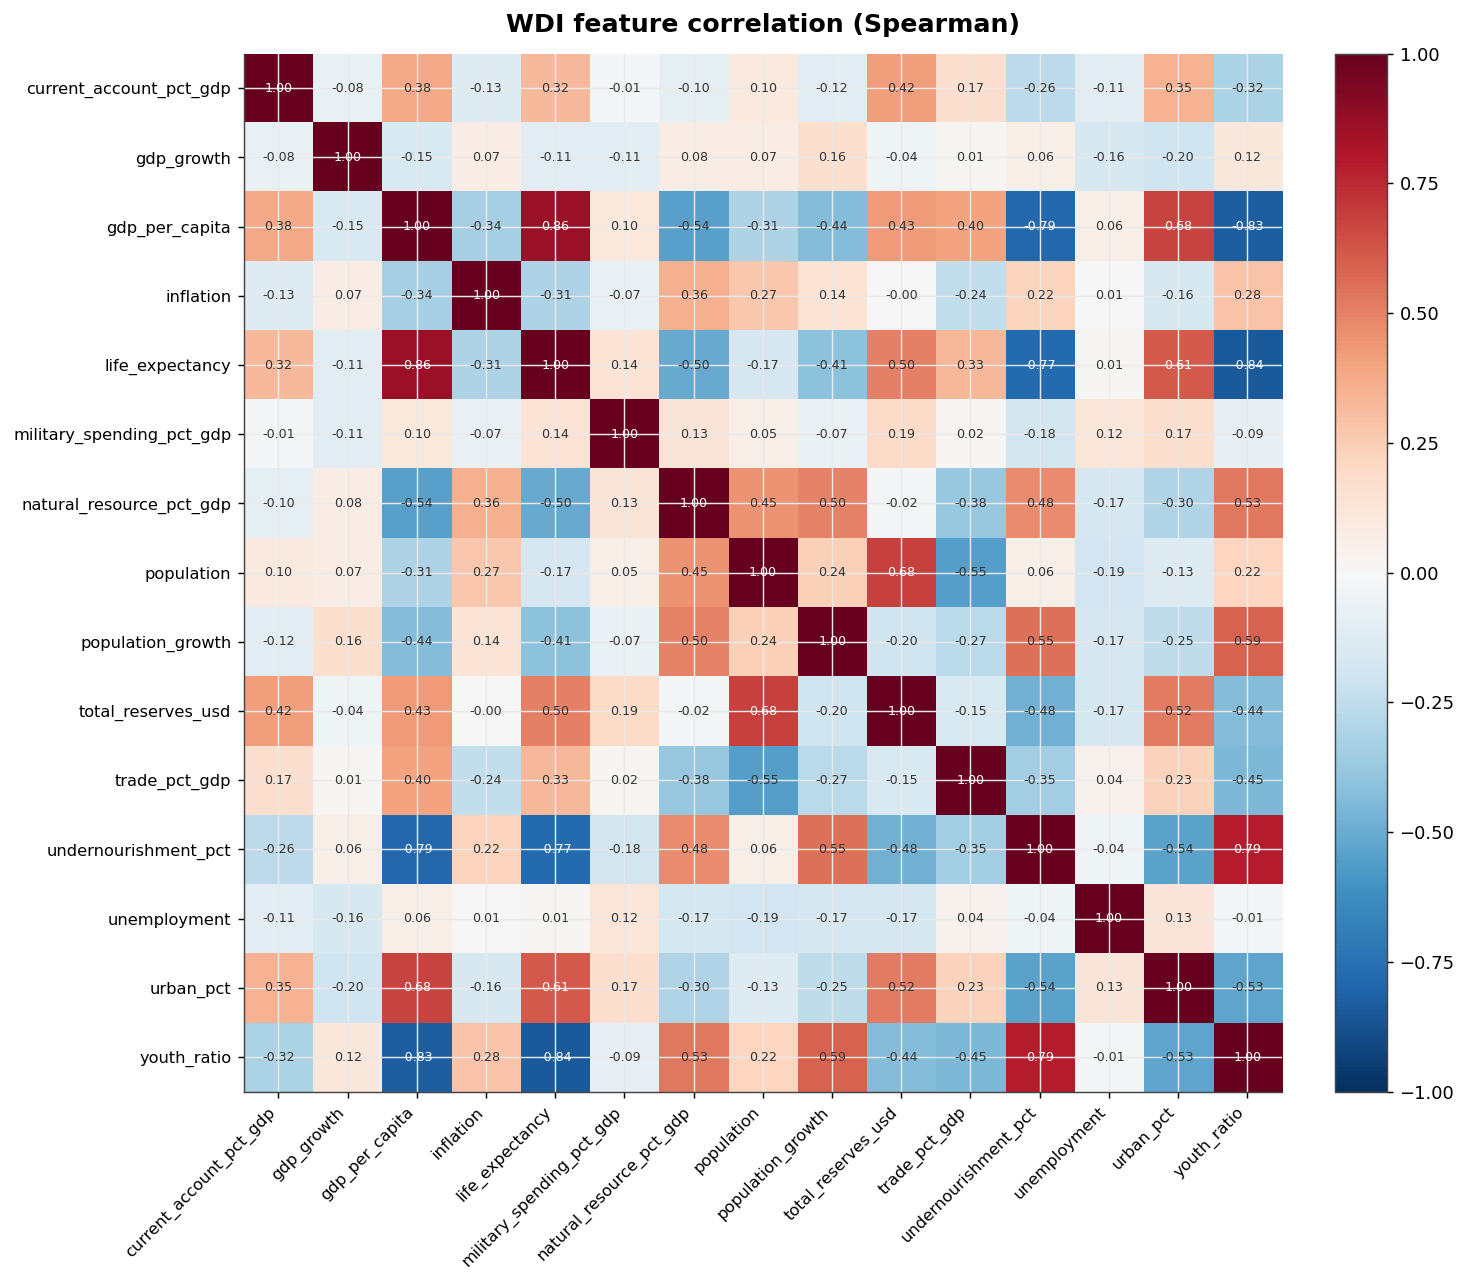

In [10]:
feats = sorted(SELECTED.values())
corr = wdi[feats].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=9)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else '#333333', fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title('WDI feature correlation (Spearman)', pad=12)
fig.tight_layout(); plt.show()

After dropping youth_unemployment (it correlated 0.92 with unemployment, the only pair over the 0.90 bar), no remaining pair is redundant. The strongest links are now a development indecators like life expectancy with GDP per capita (0.86), youth ratio with life expectancy (0.84) and with GDP per capita (0.83), and undernourishment with GDP per capita (0.79), all below 0.90, so they capture related but different factors.

I load the GPR target, average it to a yearly value per country, join it to the WDI features on the labeled countries, and rank every feature by Spearman correlation with GPR.

In [11]:
gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr['year'] = pd.to_datetime(gpr['month']).dt.year
target = gpr[(gpr.year >= 2015) & (gpr.year <= 2023)].groupby(['iso3', 'year'])['gpr'].mean().reset_index()

ms = wdi.merge(target, on=['iso3', 'year'], how='inner')
print('labeled country-years:', len(ms), '| countries:', ms.iso3.nunique())
ms[feats + ['gpr']].corr(method='spearman')['gpr'].drop('gpr').sort_values(ascending=False).to_frame('spearman_with_gpr').round(3)

labeled country-years: 387 | countries: 43


,spearman_with_gpr
total_reserves_usd,0.516
military_spending_pct_gdp,0.383
population,0.363
gdp_per_capita,0.265
life_expectancy,0.208
urban_pct,0.117
current_account_pct_gdp,0.105
inflation,0.031
gdp_growth,-0.008
unemployment,-0.090


Across 387 labeled country-years (43 countries) the correlations are weak-to-moderate, which fits GPR being a news and military driven index. I keep these features anyway since they are related to geopolitical states and might have a non linear relationship with GPR.

## 5. Validate and Save

I check the final country-year table for duplicate iso3-year keys and report non-null coverage per feature.

In [12]:
print('rows:', len(wdi), '| countries:', wdi.iso3.nunique(), '| years:', wdi.year.min(), '-', wdi.year.max())
print('duplicate iso3-year keys:', int(wdi.duplicated(['iso3', 'year']).sum()))
(wdi[feats].notna().mean() * 100).round(0).sort_values(ascending=False).to_frame('coverage_%')

rows: 2352 | countries: 217 | years: 2015 - 2025
duplicate iso3-year keys: 0


,coverage_%
life_expectancy,92.0
population,92.0
population_growth,92.0
urban_pct,92.0
youth_ratio,92.0
gdp_growth,88.0
gdp_per_capita,88.0
unemployment,87.0
current_account_pct_gdp,77.0
inflation,77.0


The table is 2,352 country-years across 217 countries, 2015 to 2025, with no duplicate iso3-year keys.

I sort by country and year, confirm the keys are unique, and save the clean country-year table (all years 2015 to 2025).

In [13]:
out = wdi.sort_values(['iso3', 'year']).reset_index(drop=True)
assert out.duplicated(['iso3', 'year']).sum() == 0, 'duplicate iso3-year keys!'
os.makedirs(OUT_DIR, exist_ok=True)
path = f'{OUT_DIR}/wdi_clean.csv'
out.to_csv(path, index=False)
print('saved:', path, '|', out.shape, '| countries:', out.iso3.nunique())
out.head()

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/worldbank/wdi_clean.csv | (2352, 20) | countries: 217


,iso3,country,region,income_group,year,current_account_pct_gdp,gdp_growth,gdp_per_capita,inflation,life_expectancy,military_spending_pct_gdp,natural_resource_pct_gdp,population,population_growth,total_reserves_usd,trade_pct_gdp,undernourishment_pct,unemployment,urban_pct,youth_ratio
0,ABW,Aruba,Latin America & Caribbean,High income,2015,3.994142,3.611480,27458.220154,0.474764,75.405,NaN,0.002388,107906.0,1.023701,8.158006e+08,140.493001,NaN,NaN,63.228837,27.456354
1,ABW,Aruba,Latin America & Caribbean,High income,2016,4.731774,1.234335,27587.249804,-0.931196,75.540,NaN,0.003344,108727.0,0.757968,9.225509e+08,136.887263,NaN,NaN,63.007788,27.499199
2,ABW,Aruba,Latin America & Caribbean,High income,2017,1.119796,3.493430,28548.890432,-1.028282,75.620,NaN,0.002827,108735.0,0.007358,9.071115e+08,138.716620,NaN,NaN,62.776849,27.542231
3,ABW,Aruba,Latin America & Caribbean,High income,2018,-0.591366,3.212471,29419.208623,3.626041,75.880,NaN,0.001885,108908.0,0.158976,9.802477e+08,138.824972,NaN,NaN,62.536764,27.533804
4,ABW,Aruba,Latin America & Caribbean,High income,2019,2.533802,1.225112,29699.180537,4.257462,76.019,NaN,0.001680,109203.0,0.270505,9.823000e+08,137.961929,NaN,NaN,62.288276,27.451991


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.